# Notebook 04 — Layer 2B Experiments
Train XGBoost, 1D CNN, and GRU. Compare on macro-F1 and per-class F1. Export winner to ONNX.

> Use GPU runtime in Colab for CNN and GRU training.

In [1]:
# ── Mount Drive ──────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, os
PROJECT = '/content/drive/MyDrive/waf-ml-project/ml'
sys.path.insert(0, PROJECT)
os.chdir(PROJECT)
print(f"Working dir: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/waf-ml-project/ml


In [2]:
%%capture
!pip install -r /content/drive/MyDrive/waf-ml-project/ml/requirements_train.txt # run once

In [3]:
%%capture
!pip install scikit-learn xgboost torch onnx onnxruntime \
             skl2onnx mlflow tqdm seaborn scipy pandas openpyxl --ignore-installed blinker

In [12]:
%%capture
!pip install onnxscript

In [4]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import mlflow
from pathlib import Path

from layer2b.candidates.xgboost_model import XGBoostModel
from layer2b.candidates.cnn_1d import CNN1DModel
from layer2b.candidates.gru import GRUModel
from layer2b.evaluate import evaluate_candidate, pick_best
from evaluation.compare_models import compare_l2b, pick_best_l2b
from evaluation.benchmark import benchmark_xgboost, benchmark_cnn_1d, benchmark_gru

SPLITS  = Path("../data/splits")
EXPORTS = Path("../exported_models")
EXPORTS.mkdir(exist_ok=True)

CLASS_NAMES = ["normal", "sqli", "xss", "lfi", "other_attack"]

mlflow.set_experiment("layer2b")

<Experiment: artifact_location='/content/drive/MyDrive/waf-ml-project/ml/mlruns/2', creation_time=1774848422739, experiment_id='2', last_update_time=1774848422739, lifecycle_stage='active', name='layer2b', tags={}, workspace='default'>

## 1. Load splits

In [5]:
X_tr_num  = np.load(SPLITS / "l2b_train_X_numeric.npy")
X_v_num   = np.load(SPLITS / "l2b_val_X_numeric.npy")
X_te_num  = np.load(SPLITS / "l2b_test_X_numeric.npy")

X_tr_tok  = np.load(SPLITS / "l2b_train_X_tokens.npy")
X_v_tok   = np.load(SPLITS / "l2b_val_X_tokens.npy")
X_te_tok  = np.load(SPLITS / "l2b_test_X_tokens.npy")

y_tr = np.load(SPLITS / "l2b_train_y.npy")
y_v  = np.load(SPLITS / "l2b_val_y.npy")
y_te = np.load(SPLITS / "l2b_test_y.npy")

import numpy as np
print(f"Train: {X_tr_num.shape}  classes: {dict(zip(*np.unique(y_tr, return_counts=True)))}")
print(f"Val:   {X_v_num.shape}")
print(f"Test:  {X_te_num.shape}")

Train: (69106, 25)  classes: {np.int64(0): np.int64(25200), np.int64(1): np.int64(1402), np.int64(2): np.int64(930), np.int64(3): np.int64(2278), np.int64(4): np.int64(39296)}
Val:   (14809, 25)
Test:  (14809, 25)


## 2. Candidate 1 — XGBoost (numeric features, CPU)

In [6]:
xgb = XGBoostModel()
xgb.train(X_tr_num, y_tr, X_v_num, y_v)
res_xgb = evaluate_candidate(xgb, X_te_num, y_te, name="xgboost")

[0]	validation_0-mlogloss:0.85927
[100]	validation_0-mlogloss:0.19915
[200]	validation_0-mlogloss:0.15222
[300]	validation_0-mlogloss:0.13116
[400]	validation_0-mlogloss:0.12189
[499]	validation_0-mlogloss:0.11704
[XGB] Best iter=499  val_f1=0.9506  val_acc=0.9419

[evaluate] xgboost
              precision    recall  f1-score   support

      normal       0.92      0.94      0.93      5400
        sqli       0.98      0.98      0.98       301
         xss       0.92      0.92      0.92       199
         lfi       1.00      0.97      0.99       488
other_attack       0.96      0.95      0.95      8421

    accuracy                           0.95     14809
   macro avg       0.96      0.95      0.95     14809
weighted avg       0.95      0.95      0.95     14809



### XGBoost feature importance

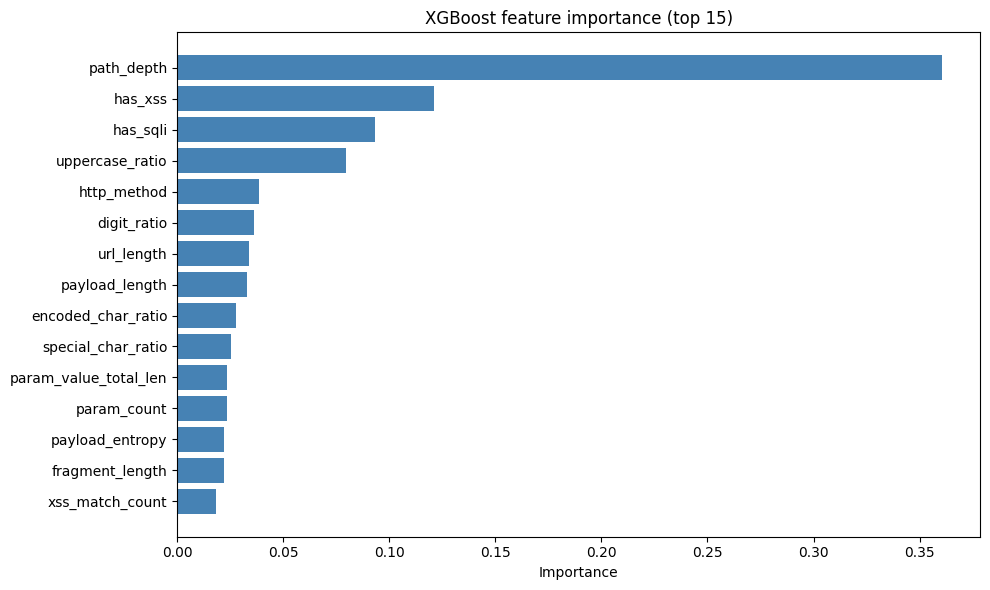

In [7]:
from feature_engineering.extractor import FEATURE_NAMES
import matplotlib.pyplot as plt

fi = xgb.feature_importance(FEATURE_NAMES)
plt.figure(figsize=(10, 6))
plt.barh(list(fi.keys())[:15], list(fi.values())[:15], color="steelblue")
plt.xlabel("Importance")
plt.title("XGBoost feature importance (top 15)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../data/processed/04_xgb_feature_importance.png", dpi=120)
plt.show()

## 3. Candidate 2 — 1D CNN (character sequences, GPU)

In [8]:
cnn = CNN1DModel()
cnn.train(X_tr_tok, y_tr, X_v_tok, y_v)
res_cnn = evaluate_candidate(cnn, X_te_tok, y_te, name="cnn_1d")

[CNN1D] Training on cuda
  epoch   5 | loss=0.0254 | val_f1=0.9915 | val_acc=0.9920
  epoch  10 | loss=0.0141 | val_f1=0.9935 | val_acc=0.9936
  epoch  15 | loss=0.0071 | val_f1=0.9947 | val_acc=0.9970
  epoch  20 | loss=0.0057 | val_f1=0.9943 | val_acc=0.9976
[CNN1D] Early stopping at epoch 23
[CNN1D] Best val F1: 0.9963

[evaluate] cnn_1d
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      5400
        sqli       1.00      1.00      1.00       301
         xss       0.97      0.99      0.98       199
         lfi       1.00      0.99      0.99       488
other_attack       1.00      1.00      1.00      8421

    accuracy                           1.00     14809
   macro avg       0.99      1.00      0.99     14809
weighted avg       1.00      1.00      1.00     14809



## 4. Candidate 3 — GRU (character sequences, GPU)

In [9]:
gru = GRUModel()
gru.train(X_tr_tok, y_tr, X_v_tok, y_v)
res_gru = evaluate_candidate(gru, X_te_tok, y_te, name="gru")

[GRU] Training on cuda
  epoch   5 | loss=0.0679 | val_f1=0.9657 | val_acc=0.9757
  epoch  10 | loss=0.0500 | val_f1=0.9816 | val_acc=0.9911
  epoch  15 | loss=0.0356 | val_f1=0.9944 | val_acc=0.9945
  epoch  20 | loss=0.0217 | val_f1=0.9953 | val_acc=0.9966
  epoch  25 | loss=0.0227 | val_f1=0.9934 | val_acc=0.9964
  epoch  30 | loss=0.0172 | val_f1=0.9959 | val_acc=0.9972
[GRU] Early stopping at epoch 31
[GRU] Best val F1: 0.9964

[evaluate] gru
              precision    recall  f1-score   support

      normal       0.99      1.00      1.00      5400
        sqli       1.00      1.00      1.00       301
         xss       0.98      0.99      0.99       199
         lfi       1.00      0.99      0.99       488
other_attack       1.00      1.00      1.00      8421

    accuracy                           1.00     14809
   macro avg       0.99      1.00      1.00     14809
weighted avg       1.00      1.00      1.00     14809



## 5. Compare all candidates

In [10]:
all_results = [res_xgb, res_cnn, res_gru]
df_compare = compare_l2b(all_results)
df_compare


=== Layer 2B Model Comparison ===
  Model  Macro F1  Accuracy  F1 (normal)  F1 (sqli)  F1 (xss)  F1 (lfi)  F1 (other_attack)
    gru    0.9950    0.9972       0.9967     0.9983    0.9875    0.9949             0.9978
 cnn_1d    0.9937    0.9966       0.9960     1.0000    0.9801    0.9949             0.9973
xgboost    0.9540    0.9457       0.9306     0.9818    0.9196    0.9855             0.9525


,Model,Macro F1,Accuracy,F1 (normal),F1 (sqli),F1 (xss),F1 (lfi),F1 (other_attack)
2,gru,0.9950,0.9972,0.9967,0.9983,0.9875,0.9949,0.9978
1,cnn_1d,0.9937,0.9966,0.9960,1.0000,0.9801,0.9949,0.9973
0,xgboost,0.9540,0.9457,0.9306,0.9818,0.9196,0.9855,0.9525


## 6. Pick winner and export ONNX

In [13]:
all_models = {"xgboost": xgb, "cnn_1d": cnn, "gru": gru}
winner_name, winner_model = pick_best_l2b(all_results, all_models)
print(f"Winner: {winner_name}")

onnx_path = str(EXPORTS / "layer2b_best.onnx")
winner_model.export_onnx(onnx_path)


[compare] L2B Winner: gru  Macro F1=0.995  Accuracy=0.9972
Winner: gru


/content/drive/MyDrive/waf-ml-project/ml/layer2b/candidates/gru.py:262: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0330 06:34:41.365000 3819 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `GRUClassifier([...]` with `torch.export.export(..., strict=False)`...


/usr/lib/python3.12/contextlib.py:144: UserWarning: The tensor attributes self.gru._flat_weights[0], self.gru._flat_weights[1], self.gru._flat_weights[2], self.gru._flat_weights[3], self.gru._flat_weights[4], self.gru._flat_weights[5], self.gru._flat_weights[6], self.gru._flat_weights[7], self.gru._flat_weights[8], self.gru._flat_weights[9], self.gru._flat_weights[10], self.gru._flat_weights[11], self.gru._flat_weights[12], self.gru._flat_weights[13], self.gru._flat_weights[14], self.gru._flat_weights[15] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)


[torch.onnx] Obtain model graph for `GRUClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 1 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
[GRU] ONNX exported → ../exported_models/layer2b_best.onnx
[GRU] avg=12.598ms  p99=19.219ms  PASS


## 7. Confusion matrices — all models

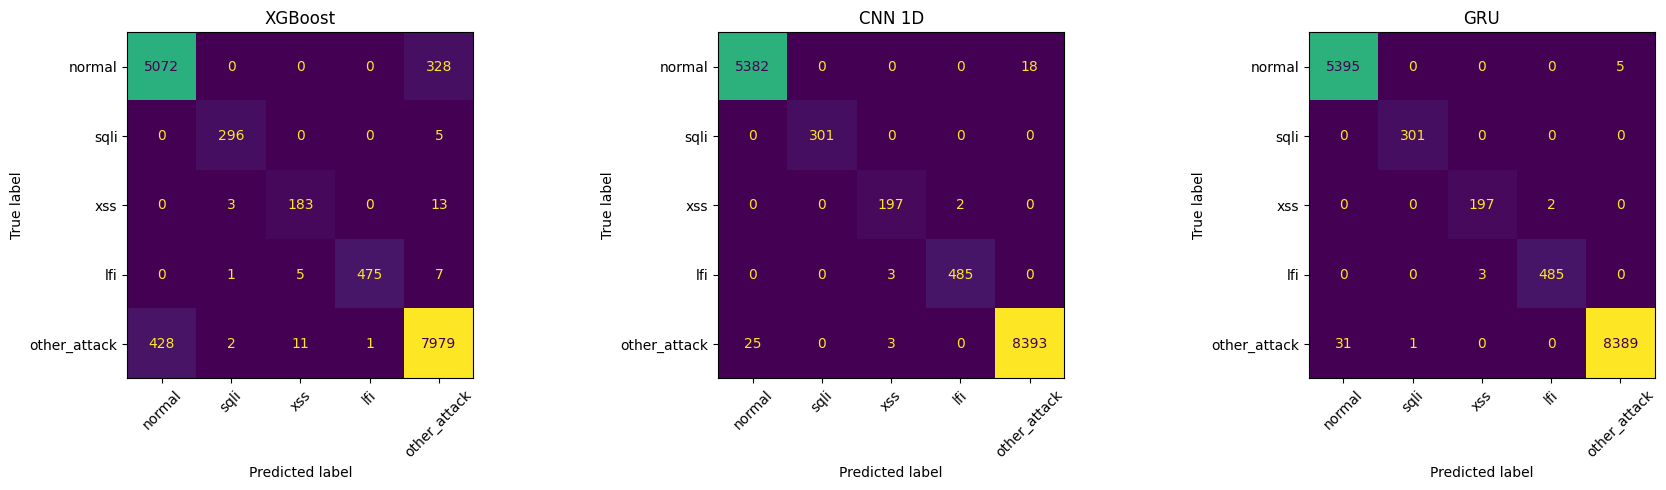

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model, X_te_input) in zip(axes, [
    ("XGBoost",  xgb, X_te_num),
    ("CNN 1D",   cnn, X_te_tok),
    ("GRU",      gru, X_te_tok),
]):
    preds = model.predict(X_te_input)
    cm    = confusion_matrix(y_te, preds, labels=list(range(5)))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig("../data/processed/04_confusion_matrices.png", dpi=120)
plt.show()

## 8. GRU attention visualisation (single anomalous request)

In [15]:
from feature_engineering.tokenizer import CharTokenizer

tok = CharTokenizer()

# pick one attack sample
attack_idx = np.where(y_te > 0)[0][0]
token_ids  = X_te_tok[attack_idx:attack_idx+1]

char_weights = gru.attention_map(token_ids, tok)

# show top 20 highest-attention characters
top20 = sorted(char_weights, key=lambda x: x[1], reverse=True)[:20]
print("Top 20 attention characters:")
for ch, w in top20:
    bar = "#" * int(w * 500)
    print(f"  '{ch}' {bar} ({w:.4f})")

Top 20 attention characters:
  'q' ######################################################################################################################################################################################################################################################################################################################################################################################################################### (0.8184)
  '?' ########################################################################################## (0.1815)
  '/'  (0.0001)
  '='  (0.0001)
  'G'  (0.0000)
  'E'  (0.0000)
  'T'  (0.0000)
  ' '  (0.0000)
  'v'  (0.0000)
  'e'  (0.0000)
  'l'  (0.0000)
  'e'  (0.0000)
  'z'  (0.0000)
  '_'  (0.0000)
  'h'  (0.0000)
  'u'  (0.0000)
  'b'  (0.0000)
  'n'  (0.0000)
  'e'  (0.0000)
  'r'  (0.0000)
